In [262]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from numpy.random import default_rng
from sklearn.model_selection import KFold
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.feature_selection import RFE
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

In [273]:
# Rrad the data
df = pd.read_csv('Raw Data.csv')
y = pd.read_csv('Target Data.csv')

In [274]:
df.head()

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.29,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,NaN,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,NaN,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,NaN,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,NaN,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN


## Wrangling Data

In [265]:
feature_with_missing_values = df.columns[df.isna().any()]
feature_with_missing_values, len(feature_with_missing_values)

(Index(['county', 'community', 'OtherPerCap', 'LemasSwornFT', 'LemasSwFTPerPop',
        'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop', 'LemasTotalReq',
        'LemasTotReqPerPop', 'PolicReqPerOffic', 'PolicPerPop',
        'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp',
        'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits',
        'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'PolicCars', 'PolicOperBudg',
        'LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'PolicBudgPerPop'],
       dtype='object'),
 25)

In [266]:
## Caculate missing rate for each feature:
missing_rate = df[feature_with_missing_values].isna().mean() * 100
missing_rate.rename('missing_rate', inplace=True)
missing_rate.head()

county             58.876630
community          59.027081
OtherPerCap         0.050150
LemasSwornFT       84.002006
LemasSwFTPerPop    84.002006
Name: missing_rate, dtype: float64

In [267]:
missing_rate_df = pd.DataFrame(missing_rate)
missing_rate_df.reset_index(inplace=True)
missing_rate_df.head()

,index,missing_rate
0,county,58.876630
1,community,59.027081
2,OtherPerCap,0.050150
3,LemasSwornFT,84.002006
4,LemasSwFTPerPop,84.002006


<Axes: xlabel='missing_rate', ylabel='index'>

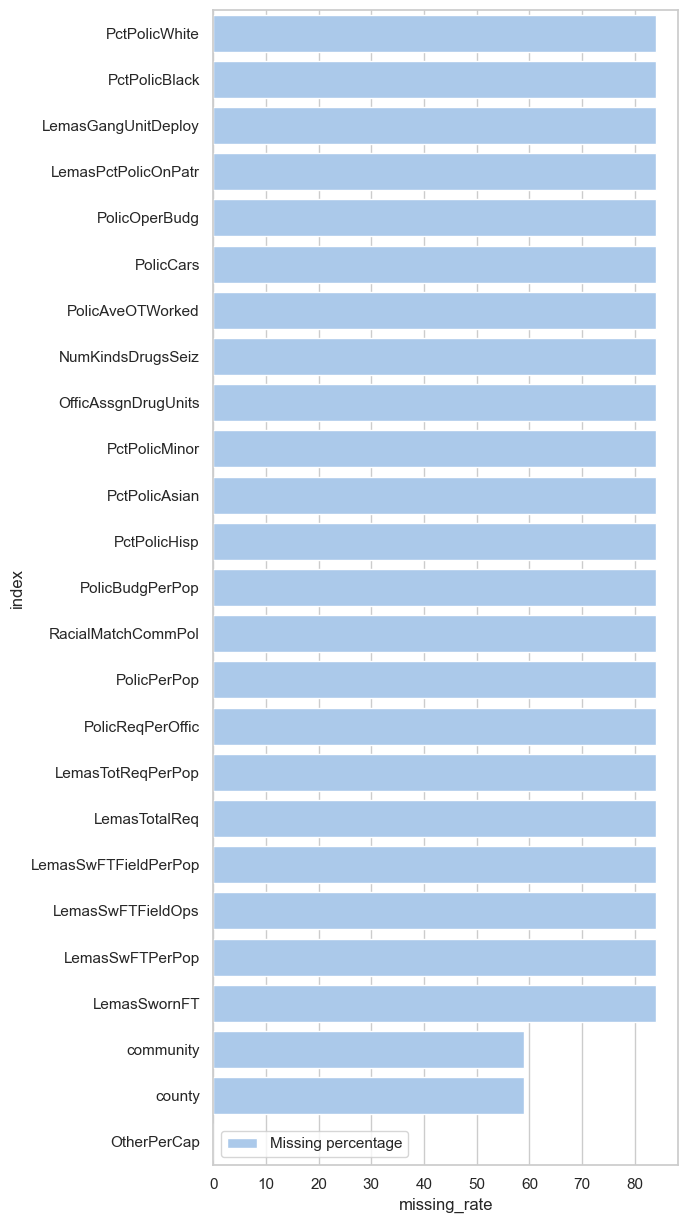

In [268]:
sns.set_theme(style="whitegrid")

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(6, 15))

# Load the example car crash dataset
crashes = missing_rate_df.sort_values(by = 'missing_rate', ascending=False)

# Plot the total crashes
sns.set_color_codes("pastel")
sns.barplot(x="missing_rate", y = 'index', data=crashes,
            label="Missing percentage", color="b")


In [269]:
high_missing_rate_features = missing_rate_df[missing_rate_df['missing_rate'] > 50]['index'].tolist()

In [270]:
good_features = [col for col in df.columns if col not in high_missing_rate_features]
len(good_features)

103

In [271]:
df_clear = df[good_features]

In [272]:
df_clear = df_clear.drop('communityname', axis = 1)

In [25]:
df_clear.fillna(0, inplace = True)
df_clear.isna().sum().sum()

0

### Clean Data

In [276]:
# Get the clean data
df_clear.head()

,state,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn
0,8,1,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,...,0.0,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32
1,53,1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,...,0.0,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00
2,24,1,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,...,0.0,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00
3,34,1,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,...,0.0,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00
4,42,1,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,...,0.0,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00


# Preprocessing Data

In [277]:
# Create a StandardScaler object
scaler = StandardScaler()

# Standardize each column of the data in df_clear
df_standardized = scaler.fit_transform(df_clear)

# Convert the standardized data back to a DataFrame and retain the original column names
df_standardized = pd.DataFrame(df_standardized, columns=df_clear.columns)

# Output the standardized DataFrame
df_standardized.head()


,state,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn
0,-1.261697,-1.564227,1.043612,-0.814997,-0.630002,0.599578,-0.161288,0.111765,-0.542791,-0.166286,...,-0.226932,-0.413507,-0.924683,-0.193320,-0.580753,-0.058180,0.500488,0.133699,0.167316,0.940399
1,1.483304,-1.564227,-0.453937,-1.853636,-0.235335,-0.056219,1.418982,-0.318466,-1.058398,0.669791,...,-0.226932,-0.024025,-0.533058,-1.075804,-0.131811,-0.663716,-0.413323,-0.555817,1.259032,-0.391447
2,-0.285697,-1.564227,-0.453937,-0.265129,1.224931,-0.793990,0.078147,-0.447535,-0.220536,-0.166286,...,-0.226932,-0.326956,-0.582011,0.027301,0.217367,-0.461871,-0.504705,-0.112556,-0.618719,-0.391447
3,0.324303,-1.564227,-0.138663,1.873246,3.237730,-2.761379,-0.161288,-0.189397,0.552875,0.042733,...,-0.226932,-0.110577,-1.512119,1.075250,0.067719,-0.007719,-0.413323,0.773964,0.516665,-0.391447
4,0.812304,-1.564227,-0.375118,0.529125,-0.630002,0.804514,-0.304949,-0.404512,-0.284987,-0.793343,...,-0.226932,-0.456783,0.543909,0.578853,-0.081928,-0.613255,-0.230561,-0.703570,-0.618719,-0.391447


In [278]:
Y = y['ViolentCrimesPerPop'] - np.mean(y['ViolentCrimesPerPop'])

In [279]:
Y.shape

(1994,)

In [283]:
correlations = np.array([np.corrcoef(df_standardized.iloc[:, i], Y)[0, 1] for i in range(df_standardized.shape[1])])

tau = 0.5

selected_features = np.where(np.abs(correlations) >= tau)[0]

X_selected = df_standardized.iloc[:, selected_features]

X = X_selected
print("Selected feature indices:", selected_features)
print(len(selected_features))

X.head()

Selected feature indices: [ 4  5 17 19 30 34 40 42 43 45 46 47 48 52 69]
15


,racepctblack,racePctWhite,pctWInvInc,pctWPubAsst,PctPopUnderPov,PctUnemployed,MalePctDivorce,FemalePctDiv,TotalPctDiv,PctFam2Par,PctKids2Par,PctYoungKids2Par,PctTeen2Par,PctIlleg,PctPersOwnOccup
0,-0.630002,0.599578,0.585942,-0.755482,-0.494815,-0.462746,1.199226,1.498536,1.393149,-0.301684,-0.148603,-0.247067,-0.119522,-0.478471,-0.063936
1,-0.235335,-0.056219,-0.256631,-0.125082,-0.275917,-0.462746,2.953471,2.412164,2.755097,-0.895963,-0.730275,-0.292792,-1.007441,-0.043478,-1.535736
2,1.224931,-0.793990,-0.593661,0.370233,-0.144578,-0.017468,0.925125,1.270128,1.120759,-0.945486,-0.875693,-1.070133,-0.798519,0.913508,-0.723708
3,3.237730,-2.761379,-0.368975,-0.530339,-0.888831,-0.165894,-0.664660,0.013889,-0.295667,0.193548,-0.390966,0.758903,0.350552,0.348017,1.915381
4,-0.630002,0.804514,1.035315,-0.935597,-1.063950,-1.204878,-1.322502,-1.642063,-1.548660,1.481151,1.402524,1.033258,1.395163,-0.826466,1.661622


In [284]:
X.shape, Y.shape

((1994, 15), (1994,))

#### a) Code up K-fold cross-validation (from scratch) to select the kernel hyperparameter and the amount of regularization in kernel ridge regularization. Your function should work for both polynomial and RBF kernels.

In [313]:
# Set a random seed for reproducibility
rng = default_rng(1)

# Define the proportions for the split
train_prop = 0.7
test_prop = 0.3

# Calculate the number of observations for each split
total_samples = df_clear.shape[0]
train_size = int(train_prop * total_samples)
test_size = total_samples - train_size

# Create a random permutation of row indices
indices = rng.choice(np.arange(total_samples), size=(total_samples), replace=False)

# Split the dataset into train, validation, and test sets
y_train = Y[indices[:train_size]]
y_test = Y[indices[(train_size + 1):]]

X_train = X.iloc[indices[:train_size]]
X_test = X.iloc[indices[(train_size + 1):]]

In [314]:
X_train.shape, y_train.shape

((1395, 15), (1395,))

In [315]:
def k_fold_cv(X, y, kernel, param_grid, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    best_params = None
    best_score = float('inf')

    for params in product(*param_grid.values()):
        param_dict = dict(zip(param_grid.keys(), params))
        mse_list = []

        for train_idx, val_idx in kf.split(X):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = KernelRidge(kernel=kernel, **param_dict)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            mse_list.append(mean_squared_error(y_val, y_pred))

        avg_mse = np.mean(mse_list)

        if avg_mse < best_score:
            best_score = avg_mse
            best_params = param_dict

    return best_params, best_score

In [316]:
param_grid_poly = {'alpha': [0.1, 1, 10], 'degree': [2, 3, 4], 'coef0': [0, 1]}
param_grid_rbf = {'alpha': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}

In [317]:
X_train = X_train.to_numpy()

In [318]:
y_train = y_train.to_numpy()

In [319]:
X_test = X_test.to_numpy()

In [320]:
y_test = y_test.to_numpy()

In [321]:
best_poly_params, best_poly_score = k_fold_cv(X_train, y_train, 'polynomial', param_grid_poly)
best_rbf_params, best_rbf_score = k_fold_cv(X_train, y_train, 'rbf', param_grid_rbf)

In [322]:
print("Best Polynomial Kernel Parameters:", best_poly_params, "MSE:", best_poly_score)
print("Best RBF Kernel Parameters:", best_rbf_params, "MSE:", best_rbf_score)

Best Polynomial Kernel Parameters: {'alpha': 1, 'degree': 2, 'coef0': 1} MSE: 0.018569851389764434
Best RBF Kernel Parameters: {'alpha': 0.1, 'gamma': 0.01} MSE: 0.018394305353792387


#### b) Use your cross-validation function to tune hyperparameters for the kernel and regular-ization amount for kernel ridge regression for both polynomial and RBF kernels. Compare the hyperparameters your function choose to those of built-in cross-validation functions in sklearn.

In [323]:
from sklearn.model_selection import GridSearchCV

# 多项式核
poly_model = KernelRidge(kernel='polynomial')
grid_poly = GridSearchCV(poly_model, param_grid_poly, cv=5, scoring='neg_mean_squared_error')
grid_poly.fit(X_train, y_train)

# RBF 核
rbf_model = KernelRidge(kernel='rbf')
grid_rbf = GridSearchCV(rbf_model, param_grid_rbf, cv=5, scoring='neg_mean_squared_error')
grid_rbf.fit(X_train, y_train)

print("Sklearn Best Polynomial Kernel Parameters:", grid_poly.best_params_, "MSE:", -grid_poly.best_score_)
print("Sklearn Best RBF Kernel Parameters:", grid_rbf.best_params_, "MSE:", -grid_rbf.best_score_)


Sklearn Best Polynomial Kernel Parameters: {'alpha': 10, 'coef0': 1, 'degree': 3} MSE: 0.01902040901344333
Sklearn Best RBF Kernel Parameters: {'alpha': 0.1, 'gamma': 0.01} MSE: 0.018870429404406173


### Analysis and comparison:

For the polynomial kernel, my function chose a smaller alpha (1) and a lower polynomial degree (2), while Sklearn chose a larger alpha (10) and a higher polynomial degree (3). From the results, my function had a slightly better MSE (0.01857 vs 0.01902), indicating that my function might have found a better balance, avoiding overfitting. Sklearn's choice seems to try to capture more complex patterns in the data with stronger regularization and a more flexible model, but it didn't perform as well.

For the RBF kernel, both my function and Sklearn selected the same alpha (0.1) and gamma (0.01). Despite both choosing the same parameters, my MSE was slightly lower (0.01839 vs 0.01887), suggesting that my function performed a bit better in this case.

RBF Kernel: My function and Sklearn were in full agreement on the parameter choice, and the performance was similar. The only difference is that my function had a slightly better MSE.
Polynomial Kernel: My function chose a relatively simpler model (lower alpha and degree) and performed slightly better in terms of MSE. Sklearn opted for a more complex model (higher alpha and degree), but it didn’t outperform my choice.

#### c) Compare the prediction errors for your final RBF and polynomial kernel ridge models to that of linear regression models from Homework 1. Which model is the best and do non-linear models offer improvements on this data set?

In [326]:
best_poly_model = KernelRidge(kernel='polynomial', **best_poly_params)
best_rbf_model = KernelRidge(kernel='rbf', **best_rbf_params)

best_poly_model.fit(X_train, y_train)
best_rbf_model.fit(X_train, y_train)

y_pred_poly = best_poly_model.predict(X_test)
y_pred_rbf = best_rbf_model.predict(X_test)

poly_mse = mean_squared_error(y_test, y_pred_poly)
rbf_mse = mean_squared_error(y_test, y_pred_rbf)

In [327]:
print(poly_mse)

0.020298909273076232


In [328]:
print(rbf_mse)

0.02038139766760383


In [329]:
X_train.shape, X_test.shape, y_test.shape

((1395, 15), (598, 15), (598,))

In [330]:
type(X_train), type(y_train), type(X_test), type(y_test)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

In [334]:
def best_subset(X_train, y_train, X_test, y_test):
    n_features = X_train.shape[1]
    best_mse = float('inf')
    best_subset = None
    
    # Exhaustively enumerate all possible feature subsets
    for k in range(1, n_features + 1):
        for subset in itertools.combinations(range(n_features), k):
            X_train_subset = X_train[:, subset]
            X_test_subset = X_test[:, subset]
            
            model = LinearRegression().fit(X_train_subset, y_train)
            y_pred = model.predict(X_test_subset)
            mse = mean_squared_error(y_test, y_pred)
            
            if mse < best_mse:
                best_mse = mse
                best_subset = subset
    
    return best_mse

# Define the Step-wise RFE method
def stepwise_rfe(X_train, y_train, X_test, y_test):
    rfe = RFE(LinearRegression(), n_features_to_select=5).fit(X_train, y_train)
    selected_features = rfe.support_
    
    X_train_selected = X_train[:, selected_features]
    X_test_selected = X_test[:, selected_features]
    
    model = LinearRegression().fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    
    return mean_squared_error(y_test, y_pred)


In [335]:
def evaluate_models(X_train, y_train, X_test, y_test, n_splits=10):
    results = {"Least Squares": [], "Ridge": [], "Lasso": [], "Elastic Net": [], "Stepwise RFE": [], 'Best Subsets': []}
    
    for _ in range(n_splits):
        
        # Least Squares
        ls_model = LinearRegression().fit(X_train, y_train)
        results["Least Squares"].append(mean_squared_error(y_test, ls_model.predict(X_test)))
        
        # Ridge Regression
        ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 10), store_cv_values=True).fit(X_train, y_train)
        results["Ridge"].append(mean_squared_error(y_test, ridge_model.predict(X_test)))
        
        # Lasso Regression
        lasso_model = LassoCV(alphas=np.logspace(-3, 3, 10), cv=5).fit(X_train, y_train)
        results["Lasso"].append(mean_squared_error(y_test, lasso_model.predict(X_test)))
        
        # Elastic Net
        elastic_net_model = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=np.logspace(-3, 3, 10), cv=5).fit(X_train, y_train)
        results["Elastic Net"].append(mean_squared_error(y_test, elastic_net_model.predict(X_test)))


        # Best Subset
        best_subset_mse = best_subset(X_train, y_train, X_test, y_test)
        results["Best Subsets"].append(best_subset_mse)  # Append MSE to the list
        
        
        # Stepwise (RFE)
        rfe = RFE(LinearRegression(), n_features_to_select=5).fit(X_train, y_train)
        stepwise_model = LinearRegression().fit(X_train[:, rfe.support_], y_train)
        results["Stepwise RFE"].append(mean_squared_error(y_test, stepwise_model.predict(X_test[:, rfe.support_])))
    
    return results

# 运行评估
results = evaluate_models(X_train, y_train, X_test, y_test)

print(results)

final_results = {key: sum(value) / len(value) for key, value in results.items()}

/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:634: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.020814781587581876, tolerance: 0.006165241603942653
  model = cd_fast.enet_coordinate_descent_gram(
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:634: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.011316972049268514, tolerance: 0.0059610141577060944
  model = cd_fast.enet_coordinate_descent_gram(
/Users/apple/Desktop/Machine Learning Lab/venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:634: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.020814781587581876, tolerance: 0.006165241603942653
  model = cd_fast.enet_c

{'Least Squares': [0.022133511428125953, 0.022133511428125953, 0.022133511428125953, 0.022133511428125953, 0.022133511428125953, 0.022133511428125953, 0.022133511428125953, 0.022133511428125953, 0.022133511428125953, 0.022133511428125953], 'Ridge': [0.02220258570284606, 0.02220258570284606, 0.02220258570284606, 0.02220258570284606, 0.02220258570284606, 0.02220258570284606, 0.02220258570284606, 0.02220258570284606, 0.02220258570284606, 0.02220258570284606], 'Lasso': [0.022224101760570252, 0.022224101760570252, 0.022224101760570252, 0.022224101760570252, 0.022224101760570252, 0.022224101760570252, 0.022224101760570252, 0.022224101760570252, 0.022224101760570252, 0.022224101760570252], 'Elastic Net': [0.022238044568067765, 0.022238044568067765, 0.022238044568067765, 0.022238044568067765, 0.022238044568067765, 0.022238044568067765, 0.022238044568067765, 0.022238044568067765, 0.022238044568067765, 0.022238044568067765], 'Stepwise RFE': [0.02442249502849725, 0.02442249502849725, 0.0244224950

In [336]:
type(final_results.keys())

dict_keys

In [337]:
final_results

{'Least Squares': 0.02213351142812595,
 'Ridge': 0.02220258570284606,
 'Lasso': 0.02222410176057025,
 'Elastic Net': 0.02223804456806777,
 'Stepwise RFE': 0.02442249502849725,
 'Best Subsets': 0.021895613700842805}

In [338]:
mse_df = pd.DataFrame(list(final_results.items()), columns = ['Model', 'Mse'])

In [339]:
mse_df

,Model,Mse
0,Least Squares,0.022134
1,Ridge,0.022203
2,Lasso,0.022224
3,Elastic Net,0.022238
4,Stepwise RFE,0.024422
5,Best Subsets,0.021896


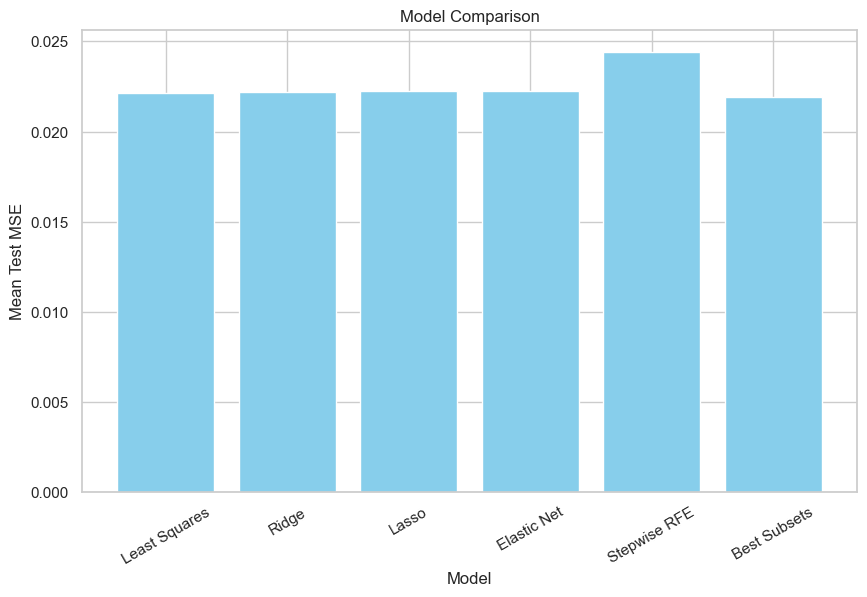

0.02251939203149168


In [341]:
# Visualize the results
plt.figure(figsize=(10, 6))
mse_means = mse_df['Mse']
plt.bar(mse_df.Model, mse_means.values, color='skyblue')
plt.ylabel("Mean Test MSE")
plt.xlabel("Model")
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()

print(mse_df.Mse.mean())

In [342]:
final_results.update({'Poly_kernel': poly_mse,
                    'Rbf_kernel': rbf_mse})

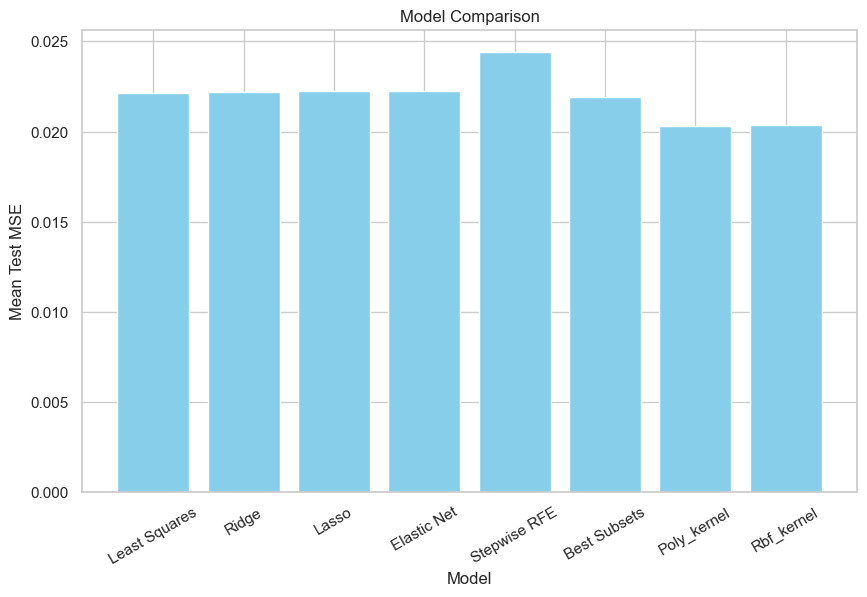

0.021974582391203767


In [343]:
mse_df = pd.DataFrame(list(final_results.items()), columns = ['Model', 'Mse'])
# Visualize the results
plt.figure(figsize=(10, 6))
mse_means = mse_df['Mse']
plt.bar(mse_df.Model, mse_means.values, color='skyblue')
plt.ylabel("Mean Test MSE")
plt.xlabel("Model")
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()
print(mse_df.Mse.mean())

### Model Performance Comparison:

Lowest MSE Models: Rbf_kernel have the smallest MSE, indicating that it performs best on the test set.
Highest MSE Model: Stepwise RFE has the largest MSE, suggesting that this method performs the worst and may suffer from overfitting or poor feature selection.
Other models (Least Squares, Ridge, Lasso, Elastic Net, Poly_kernel, Best_Subsets) have similar MSE values, meaning their predictive performance is comparable.

Best Models: Rbf_kernel achieve the lowest test MSE, making it the most suitable choices for prediction.
Traditional Regression vs. Regularization: Least Squares, Ridge, Lasso, and Elastic Net perform similarly, with no significant advantage from regularization in this dataset.
Nonlinear Methods's Advantage: The low MSE of Rbf_kernel suggests that the data may contain nonlinear patterns, making nonlinear regression a better fit.
Stepwise RFE Needs Improvement: If Stepwise RFE is to be used for feature selection, adjustments in feature selection criteria or integration with other methods may be necessary.